#### Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Index, IntervalIndex, Series

from src.algorithms import utils

#### Plot configuration

In [2]:
plt.rcParams['lines.linewidth'] = .5
plt.rcParams['lines.markersize'] = 1
plt.rcParams['patch.linewidth'] = .5
plt.rcParams['patch.edgecolor'] = 'gray'
plt.rcParams['patch.force_edgecolor'] = True
plt.rcParams['hatch.color'] = 'gray'
plt.rcParams['hatch.linewidth'] = .5
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 7
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.it'] = 'cm:italic'
plt.rcParams['axes.edgecolor'] = 'gray'
plt.rcParams['axes.linewidth'] = .3
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.titlesize'] = 7
plt.rcParams['axes.axisbelow'] = True
# plt.rcParams['axes.formatter.limits'] = [-2, 6]
plt.rcParams['xtick.major.size'] = plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.width'] = plt.rcParams['ytick.major.width'] = .3
plt.rcParams['xtick.major.pad'] = plt.rcParams['ytick.major.pad'] = 1
plt.rcParams['xtick.color'] = plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.labelsize'] = plt.rcParams['ytick.labelsize'] = 5
plt.rcParams['grid.color'] = 'gainsboro'
plt.rcParams['grid.linewidth'] = .3
plt.rcParams['grid.alpha'] = 1
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.handleheight'] = 1
MM = 1/25.4
plt.rcParams['figure.figsize'] = (150*MM, 40*MM)
plt.rcParams['figure.dpi'] = 1200
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.constrained_layout.hspace'] = 0
plt.rcParams['figure.constrained_layout.wspace'] = .1
plt.rcParams['savefig.dpi'] = 'figure'
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = .01
plt.rcParams['savefig.transparent'] = True

#### Functions

In [3]:
# KL divergence
def kl_divergence(P: Series, Q: Series) -> float:
    assert P.sum() == 1
    assert Q.sum() == 1
    assert P.index.equals(Q.index)
    return -np.log(Q.divide(P)).multiply(P).sum()

# Pooling window loss
def pooling_window_loss(P: Series, Q: Series, window_size: int) -> float:
    assert P.sum() == 1
    assert Q.sum() == 1
    assert P.index.equals(Q.index)
    windows = utils.generate_windows(index=P.index, window_size=window_size)
    P_pooled = utils.sumpool(hist=P, windows=windows)
    P_pooled = P_pooled.divide(P_pooled.sum())
    Q_pooled = utils.sumpool(hist=Q, windows=windows)
    Q_pooled = Q_pooled.divide(Q_pooled.sum())
    return P_pooled.subtract(Q_pooled).abs().sum()

#### Distributions

In [4]:
x, o = .28, .09
Q = Series([x, o, o, o, o, o, o, o, o], name=r'$Q$')
Q.index = (Index(range(len(Q))) + 1) * 10
P = {
    1: Series([o, x, o, o, o, o, o, o, o], index=Q.index, name=r'$P_1$'),
    2: Series([o, o, o, o, x, o, o, o, o], index=Q.index, name=r'$P_2$'),
    3: Series([o, o, o, o, o, o, o, o, x], index=Q.index, name=r'$P_3$')
    }

#### Scores

In [5]:
WINDOW_SIZE = 5

In [38]:
kld = {k: kl_divergence(P=v, Q=Q) for k, v in P.items()}
pwl = {k: pooling_window_loss(P=v, Q=Q, window_size=WINDOW_SIZE) for k, v in P.items()}
emd = {k: v.cumsum().subtract(Q.cumsum()).abs().mean() for k, v in P.items()}
scores = DataFrame.from_dict({'KL divergence': kld, 'pooling window loss': pwl, 'emd': emd}, orient='columns')
scores.index = scores.index.map(lambda x: fr"$P_{x}$")
scores

,KL divergence,pooling window loss,emd
$P_1$,0.215646,0.076,0.021111
$P_2$,0.215646,0.304,0.084444
$P_3$,0.215646,0.380,0.168889


#### Plot

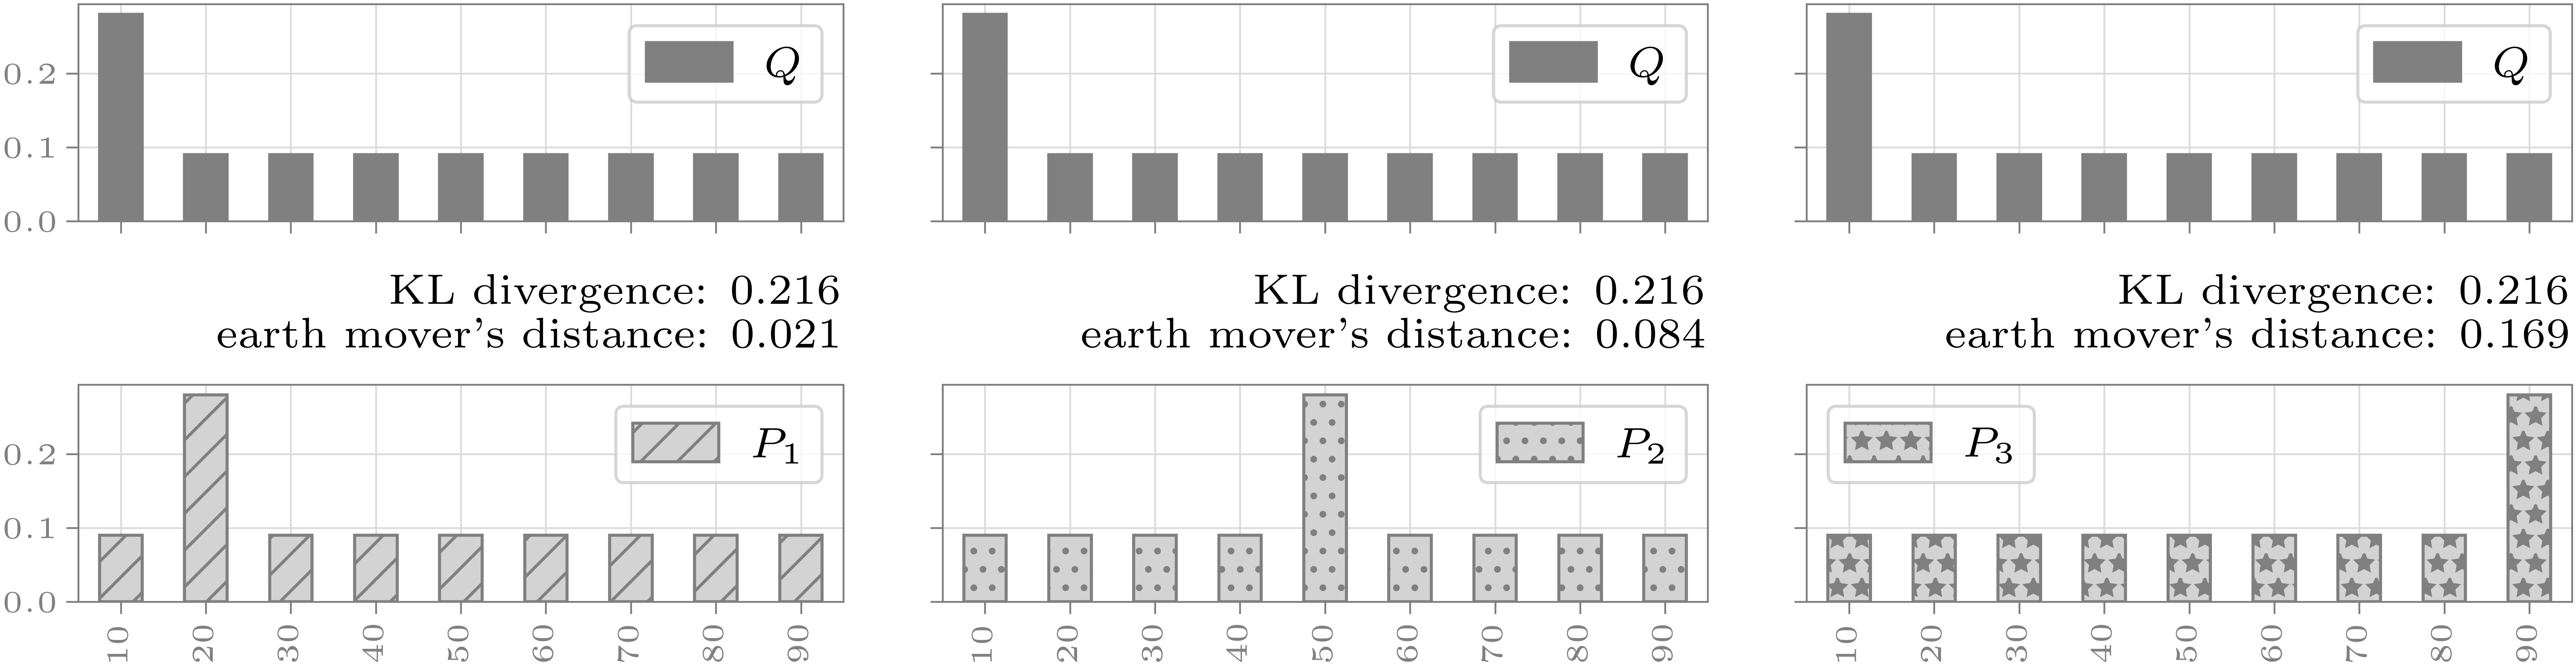

In [39]:
plot_data = pd.concat([*([Q]*len(P)), *P.values()], axis='columns')
axes = plot_data.plot.bar(
    color=[*(['gray']*len(P)), *(['lightgray']*len(P))],
    subplots=True,
    sharex=True,
    sharey=True,
    layout=(2, 3),
    )
for bar in axes[1][0].patches:
    bar.set_hatch('////')
for bar in axes[1][1].patches:
    bar.set_hatch('....')
for bar in axes[1][2].patches:
    bar.set_hatch('***')
for row in axes:
    for ax in row:
        _ = ax.set_title(None)
        _ = ax.legend()
for k in P.keys():
    _ = axes[1][k-1].set_title(f"KL divergence: {kld[k]:5.3f}\nearth mover's distance: {emd[k]:5.3f}", loc='right')
#     _ = axes[1][k-1].set_title(f"KL divergence: {kld[k]:5.3f}\npooling window loss: {pwl[k]:5.3f}", loc='right')
fig = axes[0][0].get_figure()
fig.savefig('data/toy/toy-kld-emd.pdf')

#### Issue with previous pooling window approach
Pooling window loss decreases for $P_3$

In [8]:
# Generate old pooling windows
def generate_windows_old(index: Index, window_size: int) -> IntervalIndex:
    index = index.unique()
    index = index.sort_values()
    last_idx = len(index) - 1
    offset = window_size - 1
    windows = [
        (index[left], index[min(last_idx, left+offset)])
        for left in range(len(index)-offset)
        ]
    windows = IntervalIndex.from_tuples(
        windows, closed='both', name=index.name
        )
    return windows

# Old pooling window loss
def pooling_window_loss_old(P: Series, Q: Series, window_size: int) -> float:
    assert P.sum() == 1
    assert Q.sum() == 1
    assert P.index.equals(Q.index)
    windows = generate_windows_old(index=P.index, window_size=window_size)
    P_pooled = utils.sumpool(hist=P, windows=windows)
    Q_pooled = utils.sumpool(hist=Q, windows=windows)
    # return (P_pooled/P_pooled.sum()).subtract(Q_pooled/Q_pooled.sum()).abs().sum()
    return P_pooled.subtract(Q_pooled).abs().sum()

In [9]:
WINDOW_SIZE_OLD = 4

In [10]:
pwl_old = {k: pooling_window_loss_old(P=v, Q=Q, window_size=WINDOW_SIZE_OLD) for k, v in P.items()}
scores_old = DataFrame.from_dict({'old pooling window loss': pwl_old}, orient='columns')
scores_old.index = scores_old.index.map(lambda x: fr"$P_{x}$")
scores_old

,old pooling window loss
$P_1$,0.19
$P_2$,0.95
$P_3$,0.38
